# **Add Important Libraries**

In [29]:
import os
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout,Rescaling,RandomFlip,RandomRotation,RandomZoom,BatchNormalization,GlobalAveragePooling2D,RandomContrast,RandomBrightness,Activation


from tensorflow.keras.initializers import HeNormal
from tensorflow.keras import layers
from tensorflow.data import AUTOTUNE
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping

from tensorflow.keras.models import load_model

# **Add Google Drive**

In [30]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **Activate GPU**

In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Add Kaggle API**

In [33]:
from google.colab import files
files.upload()



Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bikrammaity","key":"4d82303703c11ec6fd5dabe20c67ccee"}'}

# **Add Dataset From Kaggle**

In [34]:
!mkdir -p ~/.kaggle

!mv kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images

!unzip -q melanoma-skin-cancer-dataset-of-10000-images.zip -d ./data

!rm melanoma-skin-cancer-dataset-of-10000-images.zip

!ls ./data


Dataset URL: https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images
License(s): CC0-1.0
  0% 0.00/98.7M [00:00<?, ?B/s]
100% 98.7M/98.7M [00:00<00:00, 1.48GB/s]
melanoma_cancer_dataset


# **Set Data Directory**

In [35]:
data_dir="/content/data/melanoma_cancer_dataset"
train_dir=os.path.join(data_dir,"train")
test_dir=os.path.join(data_dir,"test")


# **Split The Data into Train and Test Set**

In [36]:
train_ds=keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(150,150),
    batch_size=32,
    shuffle=True,
    color_mode="rgb",
    label_mode="binary",
    labels="inferred"
)

test_ds=keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(150,150),
    batch_size=32,
    shuffle=False,
    color_mode="rgb",
    label_mode="binary",
    labels="inferred"
)

Found 9605 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


## **Find The Class Name**

In [10]:
class_names=train_ds.class_names
print(class_names)

['benign', 'malignant']


# **Perform Cache and Autotune for Fast Processing**

In [ ]:

train_ds=train_ds.cache().shuffle(5000).prefetch(buffer_size=AUTOTUNE)
test_ds=test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# **Perform Data Augmentation to Reduce Overfitting**

In [ ]:
data_augmentation = keras.Sequential(
    [
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.2),
    ]
)

# **Create A Custom CNN Model**

In [ ]:
he=HeNormal()
model=Sequential()
model.add(layers.Input(shape=(150, 150, 3)))
model.add(data_augmentation)
model.add(Rescaling(1./255))

model.add(Conv2D(64,(3,3),padding='same',kernel_initializer=he,use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),padding='same',kernel_initializer=he,use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),padding='same',kernel_initializer=he,use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),padding='same',kernel_initializer=he,use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, kernel_initializer=he, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))

model.add(Dense(64, kernel_initializer=he, use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))


model.add(Dense(1,activation='sigmoid'))

# **Model Summary**

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             

 Total params: 286,721 (1.09 MB)

 Trainable params: 285,569 (1.09 MB)

 Non-trainable params: 1,152 (4.50 KB)

# **Compile The Model Using Adam Optimizer**

In [ ]:
opt = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# **Perform Early Stopping to REduce Overfitting**

In [ ]:

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True,verbose=1)

# **Train Our Custom CNN Model**

In [ ]:
cnn=model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=80,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 25s 85ms/step - accuracy: 0.9067 - loss: 0.2331 - val_accuracy: 0.9060 - val_loss: 0.2395
Epoch 2/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.9023 - loss: 0.2316 - val_accuracy: 0.9080 - val_loss: 0.2292
Epoch 3/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.9002 - loss: 0.2429 - val_accuracy: 0.8930 - val_loss: 0.2671
Epoch 4/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.9058 - loss: 0.2341 - val_accuracy: 0.9050 - val_loss: 0.2520
Epoch 5/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.9045 - loss: 0.2291 - val_accuracy: 0.9060 - val_loss: 0.2494
Epoch 6/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.9102 - loss: 0.2191 - val_accuracy: 0.9140 - val_loss: 0.2293
Epoch 7/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.9113 - loss: 0.2174 - val_accuracy: 0.9050 - val_loss: 0.2449
Epoch 8/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.9058 - loss: 0.2235 - 

# **Save Our Full Custom Model in Local Environment**

In [ ]:
model.save("cnn_full_model.h5")

# **Save Our Lite Custom Model in Local Environment**

In [ ]:

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("skin_cancer_tflite.tflite", "wb") as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmpopiffsnh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139975857322704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139975857322512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139975857321744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139975857323664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139975857321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139975857323280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139975857323856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139975857323088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139975857321168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139975857321360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13997585732289

# **Load the Model**

In [90]:
model = load_model("/content/cnn_full_model.h5")


# **Check Loss & Accuracy**

In [91]:
cnn_loss,cnn_acc=model.evaluate(test_ds)
print()
print()
print("Accuracy: ",cnn_acc)
print()
print("Loss: ",cnn_loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9412 - loss: 0.1514


Accuracy:  0.9150000214576721

Loss:  0.20034003257751465


# **Evaluate Matrics**

In [14]:
#custom cnn

y_true = test_ds.map(lambda x, y: y).unbatch()
y_true = np.array([label.numpy() for label in y_true])


y_prob = model.predict(test_ds, verbose=1)
y_pred = (y_prob.ravel() >= 0.5).astype(int)


print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step

Classification Report:

              precision    recall  f1-score   support

      benign       0.88      0.96      0.92       500
   malignant       0.96      0.87      0.91       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.91      1000
weighted avg       0.92      0.92      0.91      1000


Confusion Matrix:
[[482  18]
 [ 67 433]]


In [33]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_pred)
print("ROC–AUC:", auc)


ROC–AUC: 0.915


# **View Some Predictions**

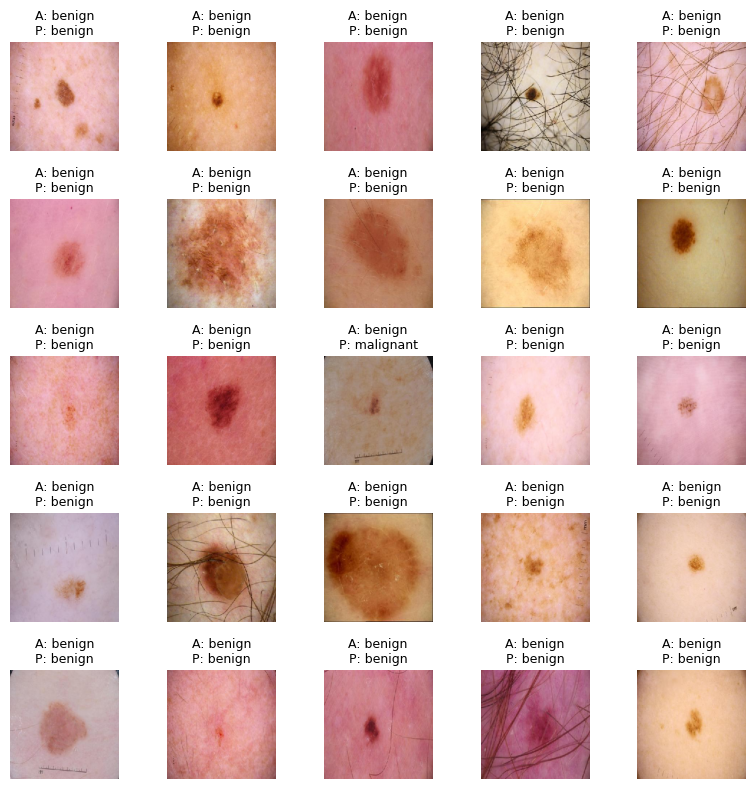

In [37]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

start, end = 30, 65

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
axes = axes.flatten()

for ax, i in zip(axes, range(start, end)):
    img_path = test_ds.file_paths[i]
    img = load_img(img_path, target_size=(224, 224))

    true_label = class_names[int(y_true[i][0])]
    pred_label = class_names[y_pred[i]]

    ax.imshow(img)
    ax.set_title(f"A: {true_label}\nP: {pred_label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


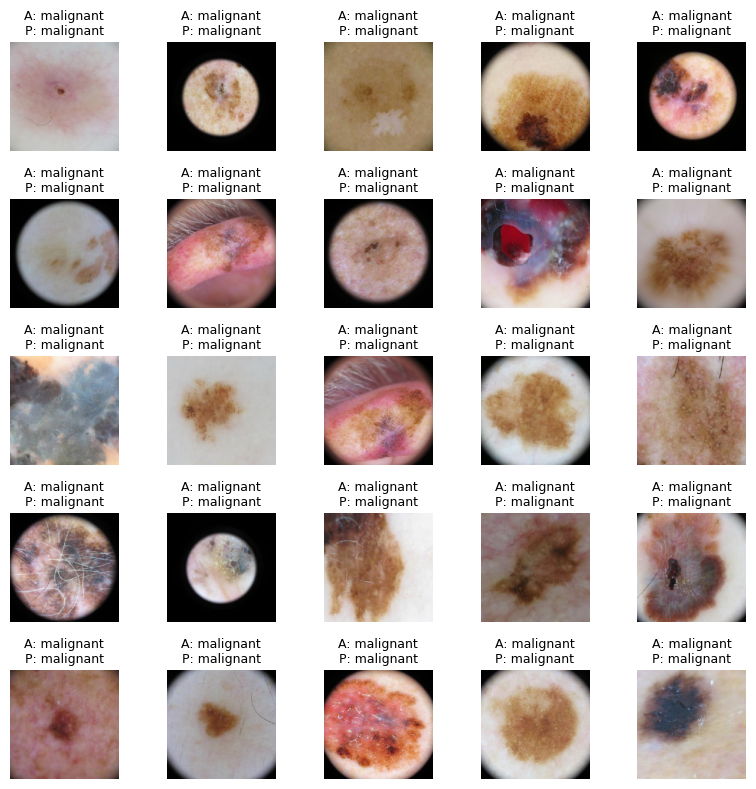

In [38]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

start, end = 900, 925

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
axes = axes.flatten()

for ax, i in zip(axes, range(start, end)):
    img_path = test_ds.file_paths[i]
    img = load_img(img_path, target_size=(224, 224))

    true_label = class_names[int(y_true[i][0])]
    pred_label = class_names[y_pred[i]]

    ax.imshow(img)
    ax.set_title(f"A: {true_label}\nP: {pred_label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()




---

# ****

# **Add pretrained model ResNet50**

In [ ]:
from tensorflow.keras.applications import ResNet50
base_model_resnet=ResNet50(include_top=False,input_shape=(224,224,3),weights='imagenet')

# **Creating train test data for Resnet**

In [37]:

train_ds_resnet=keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=True,
    color_mode="rgb",
    label_mode="binary",
    labels="inferred"
)

test_ds_resnet=keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=False,
    color_mode="rgb",
    label_mode="binary",
    labels="inferred"
)

Found 9605 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


# **Perform Cache and Autotune for Fast Processing**

In [ ]:
train_ds_resnet=train_ds_resnet.cache().shuffle(5000).prefetch(buffer_size=AUTOTUNE)
test_ds_resnet=test_ds_resnet.cache().prefetch(buffer_size=AUTOTUNE)

# **Perform Data Augmentation to Reduce Overfitting**

In [ ]:

data_aug_resnet=Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2)

])

# **Freeze Upper LAyer and Add Custom Dense Layer**

In [ ]:
#Freeze all layers
for layer in base_model_resnet.layers:
  layer.trainable = False


#unfreeze last 100 layers
for layer in base_model_resnet.layers[-50:]:
  layer.trainable=True



inp=layers.Input(shape=(224,224,3))

x=data_aug_resnet(inp)
x = base_model_resnet(x, training=False)

#add own fully connected layers

x=GlobalAveragePooling2D()(x)
x=Dense(128,activation="relu",kernel_initializer='he_normal')(x)
x=Dropout(0.4)(x)
x=Dense(64,activation="relu",kernel_initializer='he_normal')(x)
x=Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)



model_resnet=Model(inp,output)

# **Model Summary**

In [ ]:
model_resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 17,221,121 (65.69 MB)

 Non-trainable params: 6,637,184 (25.32 MB)

# **Compile The Model Using Adam Optimizer**

In [ ]:
from tensorflow.keras.optimizers import Adam

model_resnet.compile(optimizer=Adam(learning_rate=1e-6), loss='binary_crossentropy', metrics=['accuracy'])


# **Perform Early Stopping to Reduce Overfitting**

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping_resnet = EarlyStopping(monitor='val_loss', patience=6,verbose=1, restore_best_weights=True)

# **Train Resnet Model**

In [ ]:
history_resnet=model_resnet.fit(train_ds_resnet,epochs=80,validation_data=test_ds_resnet,verbose=1,callbacks=[early_stopping_resnet])

Epoch 1/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 107s 239ms/step - accuracy: 0.5293 - loss: 1.0674 - val_accuracy: 0.5690 - val_loss: 0.6785
Epoch 2/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 68s 227ms/step - accuracy: 0.5744 - loss: 0.7811 - val_accuracy: 0.7460 - val_loss: 0.5010
Epoch 3/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 69s 228ms/step - accuracy: 0.6570 - loss: 0.6358 - val_accuracy: 0.8240 - val_loss: 0.4179
Epoch 4/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 68s 227ms/step - accuracy: 0.6911 - loss: 0.5745 - val_accuracy: 0.8530 - val_loss: 0.3698
Epoch 5/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 82s 228ms/step - accuracy: 0.7258 - loss: 0.5211 - val_accuracy: 0.8640 - val_loss: 0.3389
Epoch 6/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 68s 227ms/step - accuracy: 0.7612 - loss: 0.4794 - val_accuracy: 0.8690 - val_loss: 0.3160
Epoch 7/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 71s 234ms/step - accuracy: 0.7729 - loss: 0.4618 - val_accuracy: 0.8730 - val_loss: 0.3004
Epoch 8/80
301/301 ━━━━━━━━━━━━━━━━━━━━ 73s 244ms/step - accuracy: 0.7904 - loss: 

# **Save Our Resnet Model in Local Environment**

In [ ]:
model_resnet.save("cnn_full_model_resnet.h5")


converter = tf.lite.TFLiteConverter.from_keras_model(model_resnet)
tflite_model_resnet = converter.convert()

with open("cnn_full_model_resnet.tflite", "wb") as f:
    f.write(tflite_model_resnet)


# **Load The Resnet Model**

In [31]:
model_resnet = load_model(
    "/content/drive/MyDrive/cnn_full_2model_resnet.h5"
)

# **Check The Accuracy And Loss**

In [93]:
resnet_loss,resnet_acc=model_resnet.evaluate(test_ds_resnet)
print()
print()
print("Accuracy: ",resnet_acc)
print()
print("Loss: ",resnet_loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.9612 - loss: 0.1097


Accuracy:  0.9470000267028809

Loss:  0.1238185241818428


# **Evaluate Matrics**

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


class_names = train_ds.class_names

y_true = test_ds.map(lambda x, y: y).unbatch()
y_true = np.array([label.numpy() for label in y_true])


y_prob = model_resnet.predict(test_ds_resnet, verbose=1)
y_pred = (y_prob.ravel() >= 0.5).astype(int)


print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


32/32 ━━━━━━━━━━━━━━━━━━━━ 189s 6s/step

Classification Report:

              precision    recall  f1-score   support

      benign       0.93      0.96      0.95       500
   malignant       0.96      0.93      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000


Confusion Matrix:
[[481  19]
 [ 34 466]]


In [31]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_pred)
print("ROC–AUC:", auc)


ROC–AUC: 0.9469999999999998


# **View Some Predictions**

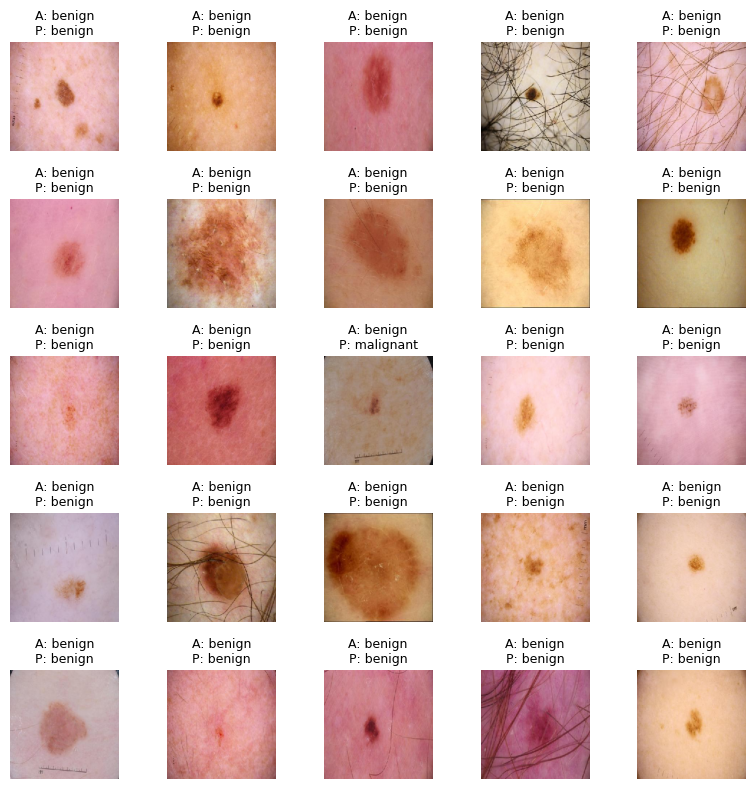

In [48]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

start, end = 30, 65

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
axes = axes.flatten()

for ax, i in zip(axes, range(start, end)):
    img_path = test_ds.file_paths[i]
    img = load_img(img_path, target_size=(224, 224))

    true_label = class_names[int(y_true[i][0])]
    pred_label = class_names[y_pred[i]]

    ax.imshow(img)
    ax.set_title(f"A: {true_label}\nP: {pred_label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


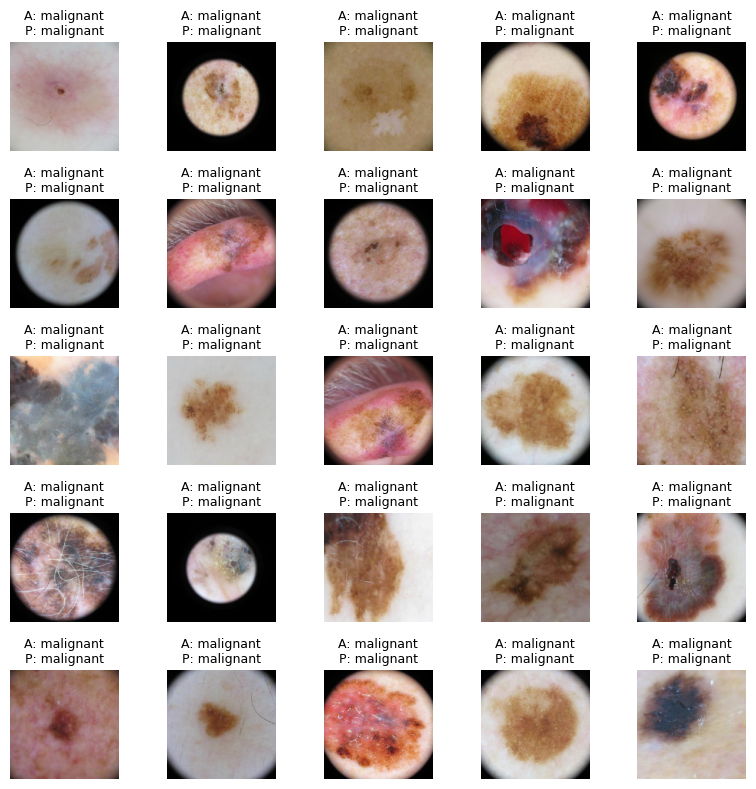

In [49]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

start, end = 900, 925

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
axes = axes.flatten()

for ax, i in zip(axes, range(start, end)):
    img_path = test_ds.file_paths[i]
    img = load_img(img_path, target_size=(224, 224))

    true_label = class_names[int(y_true[i][0])]
    pred_label = class_names[y_pred[i]]

    ax.imshow(img)
    ax.set_title(f"A: {true_label}\nP: {pred_label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()




---






---



# **Add pretrained model VGG19**

In [ ]:
from tensorflow.keras.applications import VGG19
base_model_vgg=VGG19(include_top=False,input_shape=(224,224,3),weights='imagenet')

# **Creating train test data for VGG**

In [96]:

train_ds_vgg=keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=64,
    shuffle=True,
    color_mode="rgb",
    label_mode="binary",
    labels="inferred"
)

test_ds_vgg=keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224,224),
    batch_size=64,
    shuffle=False,
    color_mode="rgb",
    label_mode="binary",
    labels="inferred"
)

Found 9605 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


# **Perform Cache and Autotune for Fast Processing**

In [ ]:
from tensorflow.data import AUTOTUNE
train_ds_vgg=train_ds_vgg.cache().shuffle(5000).prefetch(buffer_size=AUTOTUNE)
test_ds_vgg=test_ds_vgg.cache().prefetch(buffer_size=AUTOTUNE)

# **Perform Data Augmentation to Reduce Overfitting**

In [ ]:
data_aug_vgg=Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2)

])

# **Freeze Upper LAyer and Add Custom Dense Layer**

In [ ]:
#Freeze all layers
for layer in base_model_vgg.layers:
  layer.trainable = False


#unfreeze last 50 layers
for layer in base_model_vgg.layers[-50:]:
  layer.trainable=True



inp=layers.Input(shape=(224,224,3))

x=data_aug_vgg(inp)
x = base_model_vgg(x, training=False)

#add own fully connected layers

x=GlobalAveragePooling2D()(x)
x=Dense(256,activation="relu",kernel_initializer='he_normal')(x)
x=Dropout(0.4)(x)
x=Dense(256,activation="relu",kernel_initializer='he_normal')(x)
x=Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)



model_vgg=Model(inp,output)

# **Model Summary**

In [ ]:
model_vgg.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,221,761 (77.14 MB)

 Trainable params: 20,221,761 (77.14 MB)

 Non-trainable params: 0 (0.00 B)

# **Compile The Model Using Adam Optimizer And Add Callback To Reduce Overfitting**

In [ ]:
from tensorflow.keras.optimizers import Adam

model_vgg.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])
from keras.callbacks import EarlyStopping
early_stopping_vgg = EarlyStopping(monitor='val_loss', patience=6,verbose=1, restore_best_weights=True)

# **Train VGG Model**

In [ ]:
history_vgg=model_vgg.fit(train_ds_vgg,epochs=80,validation_data=test_ds_vgg,verbose=1,callbacks=[early_stopping_vgg])

Epoch 1/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.6760 - loss: 0.7179 - val_accuracy: 0.8900 - val_loss: 0.2585
Epoch 2/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 147s 976ms/step - accuracy: 0.8677 - loss: 0.3191 - val_accuracy: 0.9050 - val_loss: 0.2398
Epoch 3/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 147s 976ms/step - accuracy: 0.8914 - loss: 0.2801 - val_accuracy: 0.9040 - val_loss: 0.2292
Epoch 4/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 147s 975ms/step - accuracy: 0.9039 - loss: 0.2413 - val_accuracy: 0.9030 - val_loss: 0.2856
Epoch 5/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 147s 975ms/step - accuracy: 0.9028 - loss: 0.2297 - val_accuracy: 0.9000 - val_loss: 0.2505
Epoch 6/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 147s 976ms/step - accuracy: 0.9116 - loss: 0.2259 - val_accuracy: 0.9030 - val_loss: 0.2221
Epoch 7/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 147s 976ms/step - accuracy: 0.9178 - loss: 0.2101 - val_accuracy: 0.9030 - val_loss: 0.2436
Epoch 8/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 147s 976ms/step - accuracy: 0.9223 - lo

# **Save Our VGG Model in Local Environment**

In [ ]:
model_resnet.save("cnn_full_model_vgg.h5")


converter = tf.lite.TFLiteConverter.from_keras_model(model_resnet)
tflite_model_resnet = converter.convert()

with open("cnn_full_model_vgg.tflite", "wb") as f:
    f.write(tflite_model_resnet)


# **LOAD**

In [94]:
model_vgg = load_model(
    "/content/drive/MyDrive/cnn_full_model_vgg.h5"
)

# **Check The Accuracy And Loss**

In [97]:
loss_vgg,acc_vgg=model_vgg.evaluate(test_ds_vgg)
print("Accuracy of vgg 19: ",acc_vgg)
print("Loss of vgg 19: ",loss_vgg)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9473 - loss: 0.1506
Accuracy of vgg 19:  0.9100000262260437
Loss of vgg 19:  0.22617483139038086


# **Evaluate Matrics**

In [12]:
#custom cnn

y_true = test_ds.map(lambda x, y: y).unbatch()
y_true = np.array([label.numpy() for label in y_true])


y_prob = model_vgg.predict(test_ds, verbose=1)
y_pred = (y_prob.ravel() >= 0.5).astype(int)


print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step

Classification Report:

              precision    recall  f1-score   support

      benign       0.85      0.97      0.91       500
   malignant       0.97      0.83      0.89       500

    accuracy                           0.90      1000
   macro avg       0.91      0.90      0.90      1000
weighted avg       0.91      0.90      0.90      1000


Confusion Matrix:
[[486  14]
 [ 84 416]]


# **Add Pretrained Model DenseNet121**

In [ ]:
from tensorflow.keras.applications import DenseNet121
base_model_densenet=DenseNet121(include_top=False,input_shape=(224,224,3),weights='imagenet')


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# **Creating train test data for Resnet**

In [98]:

train_ds_den=keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=64,
    shuffle=True,
    color_mode="rgb",
    label_mode="binary",
    labels="inferred"
)

test_ds_den=keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224,224),
    batch_size=64,
    shuffle=False,
    color_mode="rgb",
    label_mode="binary",
    labels="inferred"
)

Found 9605 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


# **Perform Cache and Autotune for Fast Processing**

In [ ]:
from tensorflow.data import AUTOTUNE
train_ds_den=train_ds_den.cache().shuffle(5000).prefetch(buffer_size=AUTOTUNE)
test_ds_den=test_ds_den.cache().prefetch(buffer_size=AUTOTUNE)

# **Perform Data Augmentation to Reduce Overfitting**

In [ ]:
data_aug_den=Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2)

])

# **Freeze Upper LAyer and Add Custom Dense Layer**

In [ ]:
#Freeze all layers
for layer in base_model_densenet.layers:
  layer.trainable = False


#unfreeze last 150 layers
for layer in base_model_densenet.layers[-150:]:
  layer.trainable=True


inp=layers.Input(shape=(224,224,3))

x=data_aug_den(inp)
x = base_model_densenet(x, training=True)

#add own fully connected layers

x=GlobalAveragePooling2D()(x)
x=Dense(256,activation="relu",kernel_initializer='he_normal')(x)
x=Dropout(0.4)(x)
x=Dense(256,activation="relu",kernel_initializer='he_normal')(x)
x=Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)


model_den=Model(inp,output)

In [ ]:
model_den.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,365,953 (28.10 MB)

 Trainable params: 3,691,393 (14.08 MB)

 Non-trainable params: 3,674,560 (14.02 MB)

# **Compile The Model Using Adam Optimizer And Add Callback To Reduce Overfitting**

In [ ]:
from tensorflow.keras.optimizers import Adam

model_den.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])


from keras.callbacks import EarlyStopping
early_stopping_den = EarlyStopping(monitor='val_loss', patience=10,verbose=1, restore_best_weights=True)

# **Train Densenet Model**

In [ ]:
history_den=model_den.fit(train_ds_den,epochs=80,validation_data=test_ds_den,verbose=1,callbacks=[early_stopping_den])

Epoch 1/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 103s 448ms/step - accuracy: 0.6210 - loss: 0.7368 - val_accuracy: 0.8870 - val_loss: 0.3048
Epoch 2/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 62s 410ms/step - accuracy: 0.8496 - loss: 0.3547 - val_accuracy: 0.8930 - val_loss: 0.2474
Epoch 3/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 405ms/step - accuracy: 0.8767 - loss: 0.3022 - val_accuracy: 0.9010 - val_loss: 0.2458
Epoch 4/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 406ms/step - accuracy: 0.8863 - loss: 0.2801 - val_accuracy: 0.8970 - val_loss: 0.2481
Epoch 5/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 406ms/step - accuracy: 0.8939 - loss: 0.2651 - val_accuracy: 0.9000 - val_loss: 0.2471
Epoch 6/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 405ms/step - accuracy: 0.9027 - loss: 0.2513 - val_accuracy: 0.9050 - val_loss: 0.2459
Epoch 7/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 407ms/step - accuracy: 0.9023 - loss: 0.2473 - val_accuracy: 0.9040 - val_loss: 0.2453
Epoch 8/80
151/151 ━━━━━━━━━━━━━━━━━━━━ 61s 406ms/step - accuracy: 0.9093 - loss: 

# **Save Our Densenet Model in Local Environment**

In [ ]:
model_resnet.save("cnn_full_model_densenet.h5")


converter = tf.lite.TFLiteConverter.from_keras_model(model_resnet)
tflite_model_resnet = converter.convert()

with open("cnn_full_model_densenet.tflite", "wb") as f:
    f.write(tflite_model_resnet)


# **Load The Densenet Model**

In [99]:
model_den= load_model(
    "/content/drive/MyDrive/cnn_full_model_densenet.h5"
)

# **Check The Accuracy And Loss**

In [100]:
loss_den,acc_den=model_den.evaluate(test_ds_den)
print("Accuracy of DenseNet121: ",acc_den)
print("Loss of DenseNet121: ",loss_den)

16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 379ms/step - accuracy: 0.9317 - loss: 0.1625
Accuracy of DenseNet121:  0.8980000019073486
Loss of DenseNet121:  0.24458016455173492


# **Evaluate Matrics**

In [20]:
#Densenet
class_names = train_ds.class_names

y_true = test_ds.map(lambda x, y: y).unbatch()
y_true = np.array([label.numpy() for label in y_true])


y_prob = model_den.predict(test_ds_den, verbose=1)
y_pred = (y_prob.ravel() >= 0.5).astype(int)


print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 293ms/step

Classification Report:

              precision    recall  f1-score   support

      benign       0.85      0.96      0.90       500
   malignant       0.96      0.83      0.89       500

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000


Confusion Matrix:
[[481  19]
 [ 83 417]]


# **Compare**

In [108]:


def evaluate_model(model, test_ds, model_name):
    y_true = test_ds.map(lambda x, y: y).unbatch()
    y_true = np.array([y.numpy() for y in y_true]).ravel()

    y_prob = model.predict(test_ds, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }


In [109]:

results = []

results.append(evaluate_model(model, test_ds, "Custom CNN"))
results.append(evaluate_model(model_vgg, test_ds_resnet, "VGG16"))
results.append(evaluate_model(model_resnet, test_ds_resnet, "ResNet50"))
results.append(evaluate_model(model_den, test_ds_resnet, "DenseNet121"))

total_df = pd.DataFrame(results)
total_df


,Model,Accuracy,Precision,Recall,F1-score
0,Custom CNN,0.915,0.960089,0.866,0.910620
1,VGG16,0.910,0.976744,0.840,0.903226
2,ResNet50,0.947,0.960825,0.932,0.946193
3,DenseNet121,0.898,0.956422,0.834,0.891026


In [110]:
total_df["Loss"]=cnn_loss,loss_vgg,resnet_loss,loss_den

In [111]:
total_df

,Model,Accuracy,Precision,Recall,F1-score,Loss
0,Custom CNN,0.915,0.960089,0.866,0.910620,0.200340
1,VGG16,0.910,0.976744,0.840,0.903226,0.226175
2,ResNet50,0.947,0.960825,0.932,0.946193,0.123819
3,DenseNet121,0.898,0.956422,0.834,0.891026,0.244580


In [112]:
df_new = total_df.copy()
df_new.iloc[:, 1:] = (df_new.iloc[:, 1:] * 100).round(2)
df_new

,Model,Accuracy,Precision,Recall,F1-score,Loss
0,Custom CNN,91.5,96.01,86.6,91.06,20.03
1,VGG16,91.0,97.67,84.0,90.32,22.62
2,ResNet50,94.7,96.08,93.2,94.62,12.38
3,DenseNet121,89.8,95.64,83.4,89.10,24.46


In [105]:
df_new.to_csv("Derma skin AI.csv",index=False)

In [4]:
df=pd.read_csv("/content/Derma skin AI.csv")
df

,Model,Accuracy,Precision,Recall,F1-score,Loss
0,Custom CNN,91.5,96.01,86.6,91.06,20.03
1,VGG16,91.0,97.67,84.0,90.32,22.62
2,ResNet50,94.7,96.08,93.2,94.62,12.38
3,DenseNet121,89.8,95.64,83.4,89.10,24.46


# **Performance Vizualization**

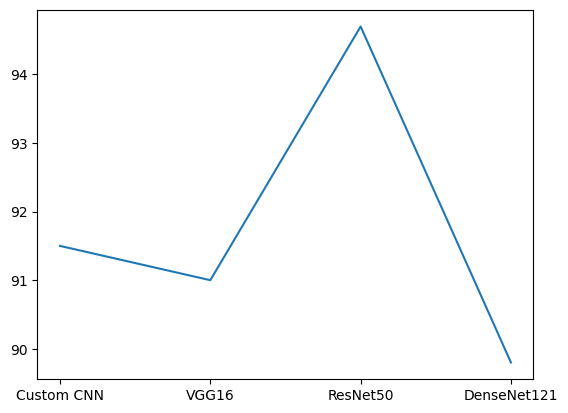

In [13]:
plt.plot(df["Model"],df["Accuracy"])

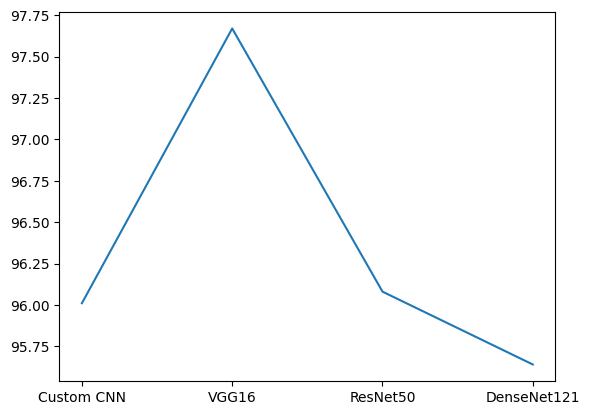

In [14]:
plt.plot(df["Model"],df["Precision"])

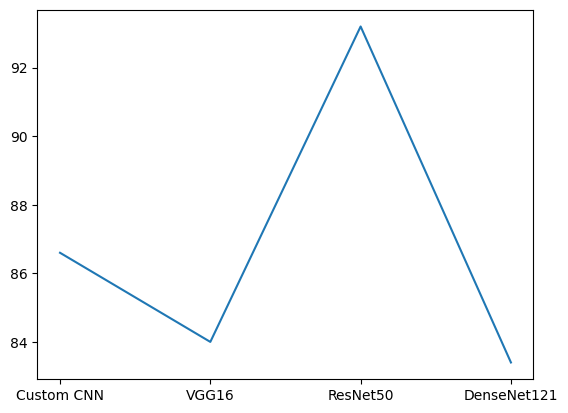

In [15]:
plt.plot(df["Model"],df["Recall"])

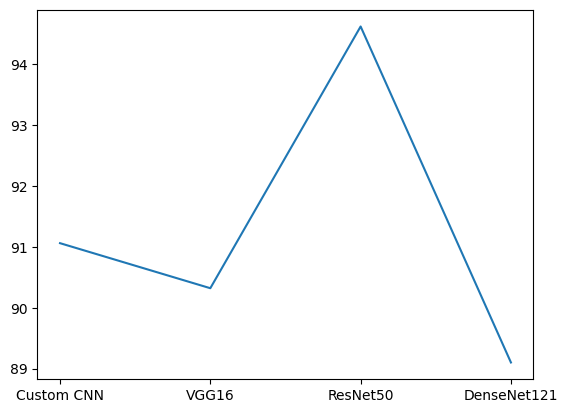

In [16]:
plt.plot(df["Model"],df["F1-score"])

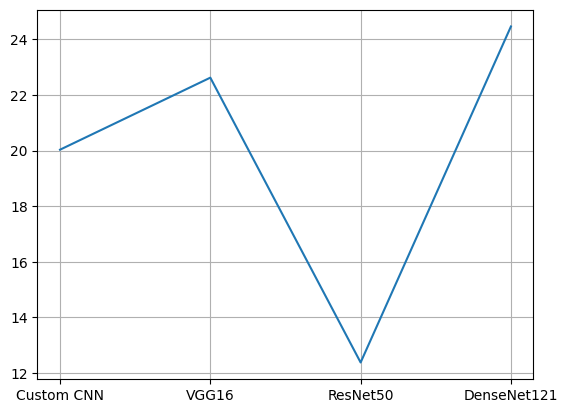

In [17]:
plt.plot(df["Model"],df["Loss"])

In [ ]:
plt.plot(df["Model"],df["Accuracy"])
plt.plot(df["Model"],df["Precision"])
plt.plot(df["Model"],df["Recall"])
plt.plot(df["Model"],df["F1-score"])
plt.legend(["Accuracy","Precision","Recall","F1-score","Loss"],loc="best")
plt.grid()

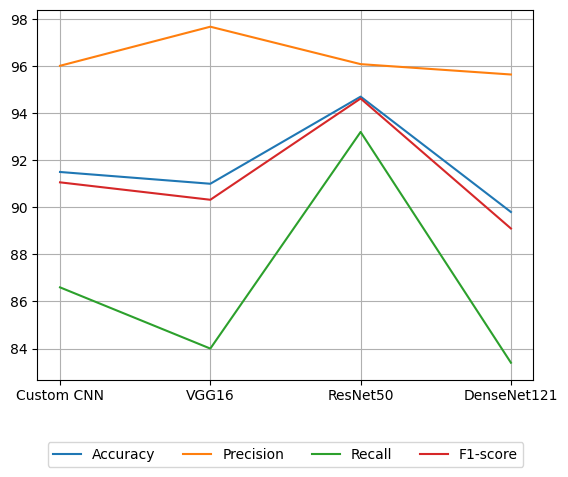

In [24]:
fig, ax = plt.subplots()
ax.plot(df["Model"], df["Accuracy"], label="Accuracy")
ax.plot(df["Model"], df["Precision"], label="Precision")
ax.plot(df["Model"], df["Recall"], label="Recall")
ax.plot(df["Model"], df["F1-score"], label="F1-score")

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
ax.grid(True)


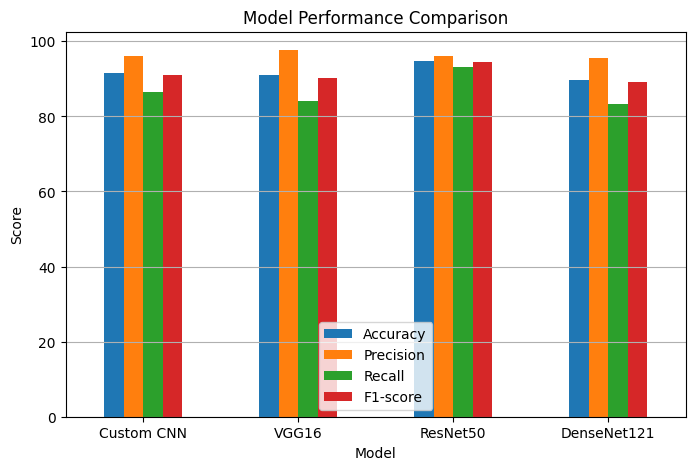

In [25]:
df.set_index("Model")[["Accuracy","Precision","Recall","F1-score"]].plot(
    kind="bar", figsize=(8,5)
)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.grid(axis="y")


Text(0.5, 1.0, 'Confusion Matrix')

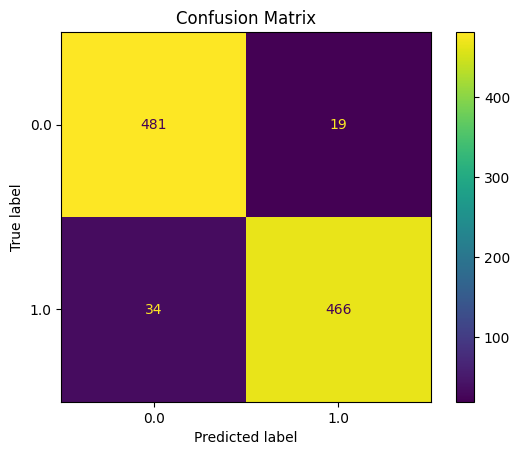

In [39]:
#Resnet


ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.title("Confusion Matrix")
